In [1]:
from google.colab import drive
drive.mount("/content/drive")

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [2]:
import h5py
import numpy as np
f = h5py.File("/content/drive/My Drive/AIML/SVHN_single_grey1.h5", "r")
print(f)


<HDF5 file "SVHN_single_grey1.h5" (mode r)>


In [3]:
f1 =f.keys()
f1

KeysView(<HDF5 file "SVHN_single_grey1.h5" (mode r)>)

6
Before

X_test shape (18000, 32, 32)
X_train shape (42000, 32, 32)
X_val shape (60000, 32, 32)
y_test shape (18000,)
y_train shape (42000,)
y_val shape (60000,)
After



Using TensorFlow backend.


X_test shape (18000, 32, 32, 1)
X_train shape (42000, 32, 32, 1)
X_val shape (60000, 32, 32, 1)
y_test shape (18000,)
y_train shape (42000,)
y_val shape (60000,)


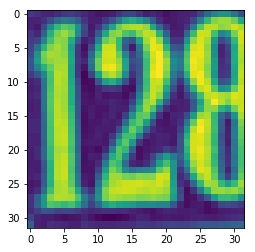

In [4]:
X_test= f['X_test'][:]
X_train = f['X_train'][:]
X_val = f['X_val'][:]
y_test = f['y_test'][:]
y_train = f['y_train'][:]
y_val = f['y_val'][:]
def pri(X_test, X_train, X_val, y_test, y_train, y_val):
  print("X_test shape",X_test.shape)
  print("X_train shape",X_train.shape)
  print("X_val shape",X_val.shape)
  print("y_test shape",y_test.shape)
  print("y_train shape",y_train.shape)
  print("y_val shape",y_val.shape)

import matplotlib.pyplot as plt
plt.imshow(X_train[0])
print(y_train[1])
print("Before\n")
pri(X_test, X_train, X_val, y_test, y_train, y_val)

X_test = X_test.reshape(18000,32,32,1)
X_train = X_train.reshape(42000,32,32,1)
X_val = X_val.reshape(60000,32,32,1)

print("After\n")
from keras.utils import np_utils
pri(X_test, X_train, X_val, y_test, y_train, y_val)
y_train_classes = np_utils.to_categorical(y_train, 10) 
y_test_classes = np_utils.to_categorical(y_test, 10) 

In [17]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D
from keras import regularizers

weight_decay = 1e-4
# create  model
model = Sequential()
model.add(Convolution2D(128,5,5,activation='relu', input_shape = (32,32,1)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(32, (5,5), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
 
model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))
 
model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))
 
model.add(Flatten())
model.add(Dense(10, activation='softmax'))
 

model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='sgd')
model.fit(X_train, y_train_classes,
              batch_size=128, nb_epoch=40,
              verbose=1,
              validation_data=(X_test, y_test_classes))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:9: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(128, (5, 5), activation="relu", input_shape=(32, 32, 1...)`
  if __name__ == '__main__':
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:44: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.


Train on 42000 samples, validate on 18000 samples
Epoch 1/40
42000/42000 [==============================] - 12s 288us/step - loss: 1.6274 - acc: 0.5415 - val_loss: 0.8816 - val_acc: 0.7438
Epoch 2/40
42000/42000 [==============================] - 10s 246us/step - loss: 0.7727 - acc: 0.7768 - val_loss: 0.5856 - val_acc: 0.8364
Epoch 3/40
42000/42000 [==============================] - 10s 244us/step - loss: 0.6462 - acc: 0.8164 - val_loss: 0.4937 - val_acc: 0.8655
Epoch 4/40
42000/42000 [==============================] - 10s 242us/step - loss: 0.5803 - acc: 0.8348 - val_loss: 0.4957 - val_acc: 0.8639
Epoch 5/40
42000/42000 [==============================] - 10s 242us/step - loss: 0.5371 - acc: 0.8506 - val_loss: 0.5765 - val_acc: 0.8369
Epoch 6/40
42000/42000 [==============================] - 10s 242us/step - loss: 0.5006 - acc: 0.8602 - val_loss: 0.4321 - val_acc: 0.8827
Epoch 7/40
42000/42000 [==============================] - 10s 241us/step - loss: 0.4734 - acc: 0.8690 - val_loss: 0.